In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from statsmodels.regression.linear_model import OLS
from functions import *

In [5]:
#Read in data file (see data_processing.ipynb for how this file is generated)
#Keep only Lec, CG, WG, and SQ codes (see paper for discussion of feature selection)
codes_and_CIs = pd.read_csv('Published Data/combined_COPUS_CI_data.csv')
measured_data = pd.read_csv('Measured Data/MASTER.csv')
#concat 
codes_and_CIs = pd.concat([codes_and_CIs, measured_data], axis=0, ignore_index=True)

#The target variable is the effect size
target = codes_and_CIs['Effect Size'].to_numpy()

In [6]:
    ##plotting LOO predictions with error bars representing uncertainty across different fits
def LOO_plot(target, LOO_predictions_mean, LOO_predictions_std):
    x, y = target, LOO_predictions_mean
    plt.plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)

    where_low_error = np.where(LOO_predictions_std < .3)
    where_high_error = np.where(LOO_predictions_std >= .3)
    low_x, low_y = x[where_low_error], y[where_low_error]
    high_x, high_y = x[where_high_error], y[where_high_error]

    m, b = np.polyfit(x, y, 1)
    xi = np.linspace(np.min(x), np.max(x), 100)


    plt.scatter(low_x, low_y, label='Prediction uncertainty < .3', color='blue', alpha=0.7)
    plt.errorbar(low_x, low_y, yerr=LOO_predictions_std[where_low_error], fmt='o', color='blue', alpha=0.5)

    plt.scatter(high_x, high_y, label='Prediction uncertainty > .3', color='red', alpha=0.7)
    plt.errorbar(high_x, high_y, yerr=LOO_predictions_std[where_high_error], fmt='o', color='red', alpha=0.5)

    plt.xlabel(f'Measured Effect Size')
    plt.ylabel(f'Predicted Effect Size')
    plt.ylim(0, 3)
    #plt.title(f'Leave-One-Out Predictions vs Target')
    plt.legend()
    plt.savefig('Figs/LOO.png', dpi=300)
    plt.show()

    print(f'R^2: {np.corrcoef(x, y)[0, 1]**2:.3f}')
    print(f'Mean absolute error: {np.mean(np.abs(y-x)):.4f}')
    print('-----')
    print(f'R^2 removing high uncertainty: {np.corrcoef(low_x, low_y)[0, 1]**2:.3f}')
    print(f'MAE removing high uncertainty: {np.mean(np.abs(low_y-low_x)):.4f}')



Iteration 1 finished with AIC 68.18
Iteration 1001 finished with AIC 173.14
Iteration 2001 finished with AIC 114.26
Iteration 3001 finished with AIC 51.69
Iteration 4001 finished with AIC 162.31
Iteration 5001 finished with AIC 156.47
Iteration 6001 finished with AIC 165.02
Iteration 7001 finished with AIC 103.88
Iteration 8001 finished with AIC 160.95
Iteration 9001 finished with AIC 217.76


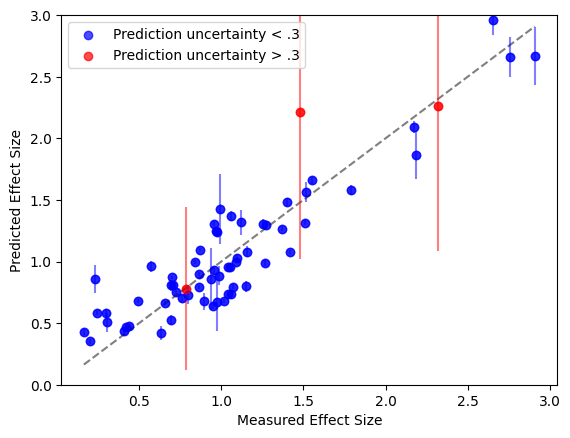

R^2: 0.834
Mean absolute error: 0.1949
-----
R^2 removing high uncertainty: 0.841
MAE removing high uncertainty: 0.1914


In [ ]:
#Maximum number of codes, choose CG over CQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 5)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 169.24
Iteration 1001 finished with AIC 121.35
Iteration 2001 finished with AIC 151.59
Iteration 3001 finished with AIC 82.88
Iteration 4001 finished with AIC 74.47
Iteration 5001 finished with AIC 174.45
Iteration 6001 finished with AIC 94.04
Iteration 7001 finished with AIC 138.89
Iteration 8001 finished with AIC 94.94
Iteration 9001 finished with AIC 133.3


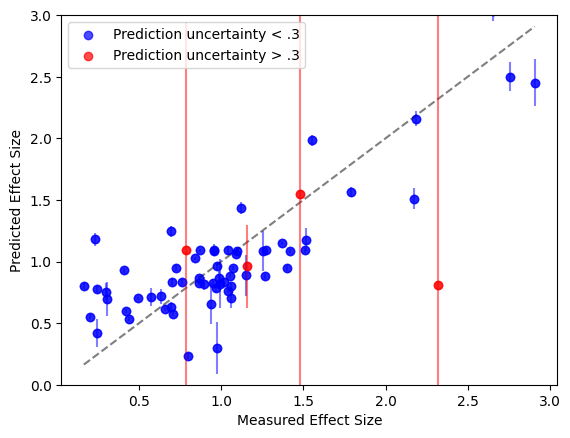

R^2: 0.616
Mean absolute error: 0.2755
-----
R^2 removing high uncertainty: 0.692
MAE removing high uncertainty: 0.2595


In [ ]:
#Maximum number of codes, choose CQ over CG
#CG does way better


#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CQ', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 5)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 117.25
Iteration 1001 finished with AIC 129.27
Iteration 2001 finished with AIC 117.45
Iteration 3001 finished with AIC 111.34
Iteration 4001 finished with AIC 109.27
Iteration 5001 finished with AIC 92.14
Iteration 6001 finished with AIC 114.58
Iteration 7001 finished with AIC 111.72
Iteration 8001 finished with AIC 124.0
Iteration 9001 finished with AIC 103.64


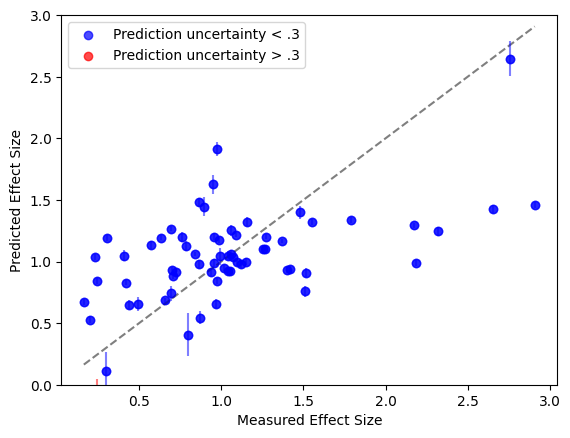

R^2: 0.310
Mean absolute error: 0.3700
-----
R^2 removing high uncertainty: 0.294
MAE removing high uncertainty: 0.3679


In [ ]:
#replace OG and WG with PQ
#does way worse

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'PQ', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 5)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 102.71
Iteration 1001 finished with AIC 95.5
Iteration 2001 finished with AIC 117.98
Iteration 3001 finished with AIC 79.75
Iteration 4001 finished with AIC 86.4
Iteration 5001 finished with AIC 77.71
Iteration 6001 finished with AIC 87.71
Iteration 7001 finished with AIC 106.99
Iteration 8001 finished with AIC 91.13
Iteration 9001 finished with AIC 74.67


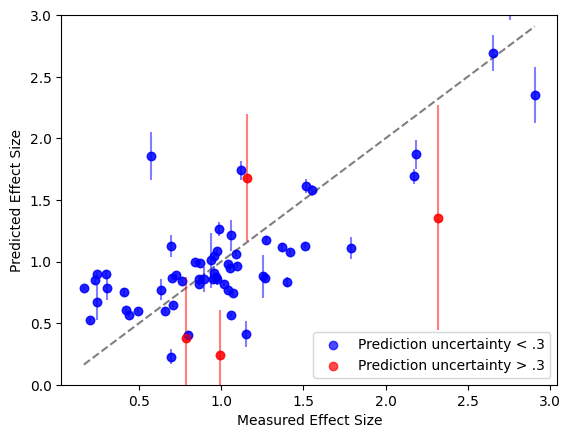

R^2: 0.463
Mean absolute error: 0.3365
-----
R^2 removing high uncertainty: 0.608
MAE removing high uncertainty: 0.2841


In [ ]:
#remove lec

#these will be input features for the model
data = codes_and_CIs[[ 'WG', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 5)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 95.28
Iteration 1001 finished with AIC 50.72
Iteration 2001 finished with AIC 93.1
Iteration 3001 finished with AIC 38.54
Iteration 4001 finished with AIC 71.56
Iteration 5001 finished with AIC 116.16
Iteration 6001 finished with AIC 35.94
Iteration 7001 finished with AIC 40.72
Iteration 8001 finished with AIC 38.7
Iteration 9001 finished with AIC 100.65


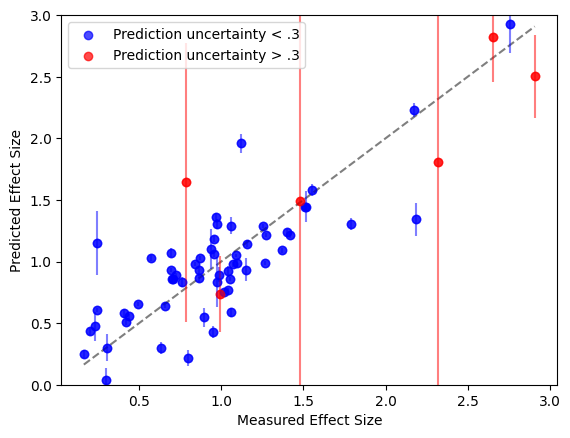

R^2: 0.716
Mean absolute error: 0.2412
-----
R^2 removing high uncertainty: 0.648
MAE removing high uncertainty: 0.2283


In [ ]:
#remove OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 5)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 116.78
Iteration 1001 finished with AIC 102.22
Iteration 2001 finished with AIC 124.78
Iteration 3001 finished with AIC 111.62
Iteration 4001 finished with AIC 112.56
Iteration 5001 finished with AIC 124.87
Iteration 6001 finished with AIC 106.09
Iteration 7001 finished with AIC 119.09
Iteration 8001 finished with AIC 124.29
Iteration 9001 finished with AIC 105.49


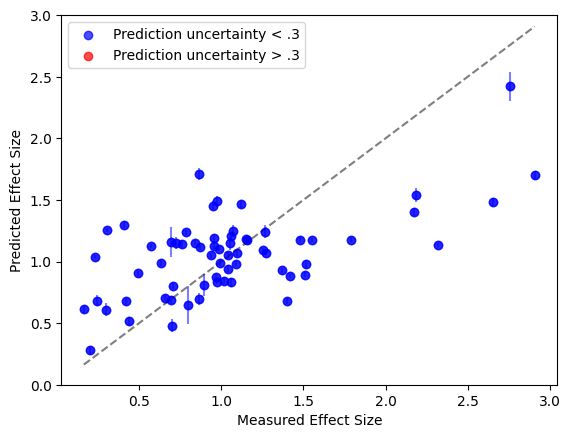

R^2: 0.373
Mean absolute error: 0.3581
-----
R^2 removing high uncertainty: 0.373
MAE removing high uncertainty: 0.3581


In [15]:
#remove WG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 5)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 100.47
Iteration 1001 finished with AIC 131.21
Iteration 2001 finished with AIC 93.19
Iteration 3001 finished with AIC 83.65
Iteration 4001 finished with AIC 76.13
Iteration 5001 finished with AIC 79.59
Iteration 6001 finished with AIC 83.21
Iteration 7001 finished with AIC 97.34
Iteration 8001 finished with AIC 130.11
Iteration 9001 finished with AIC 127.78


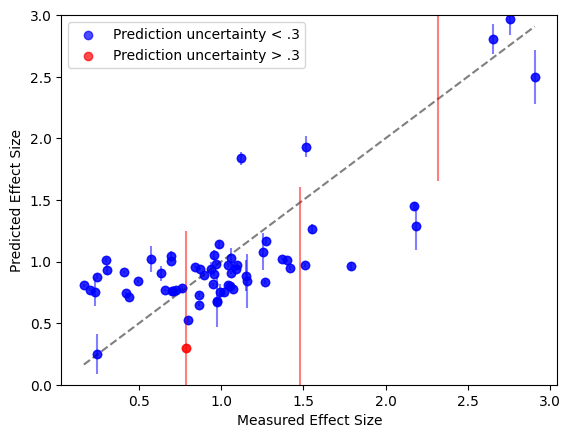

R^2: 0.460
Mean absolute error: 0.3490
-----
R^2 removing high uncertainty: 0.599
MAE removing high uncertainty: 0.2939


In [16]:
#remove SQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG',  ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 5)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

## Model Complexity

In [ ]:
#up to third order terms

def add_cross_terms_3(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))

    #third order terms
    cross_21 = (data.reshape(pts, 1, features)**2 * data.reshape(pts, features, 1))
    cross_12 = (data.reshape(pts, 1, features) * data.reshape(pts, features, 1)**2)


    cross_factors = np.hstack((cross_factors, cross_21[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))
    cross_factors = np.hstack((cross_factors, cross_12[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))


    data = np.hstack((data, cross_factors))

    

    data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 2:3]))  # interaction term for first three features
    if features >= 4:
        data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 3:4]))  # interaction term for first second and fourth features
        data = np.hstack((data, data[:, :1]*data[:, 2:3]* data[:, 3:4]))  # interaction term for first third and fourth features
        data = np.hstack((data, data[:, 1:2] * data[:, 2:3] * data[:, 3:4]))  # interaction term for second third and fourth features
    
    #######################
    if features >= 5:
        data = np.hstack((data, data[:, :1] * data[:, 1:2] * data[:, 4:5]))  # interaction term for first second and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 2:3] * data[:, 4:5]))  # interaction term for first third and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 3:4] * data[:, 4:5]))  # interaction term for first fourth and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:,  2:3] * data[:, 4:5]))  # interaction term for second third and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:, 3:4] * data[:, 4:5]))  # interaction term for second fourth and fifth features
        data = np.hstack((data, data[:, 2:3] * data[:, 3:4] * data[:, 4:5]))  # interaction term for third fourth and fifth features
        ########################
    data = np.hstack((data, data[:, :4]**3))  #third order ter

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


Iteration 1 finished with AIC 99.01
Iteration 1001 finished with AIC 68.95
Iteration 2001 finished with AIC 158.23
Iteration 3001 finished with AIC 81.52
Iteration 4001 finished with AIC 107.05
Iteration 5001 finished with AIC 63.31
Iteration 6001 finished with AIC 88.6
Iteration 7001 finished with AIC 112.26
Iteration 8001 finished with AIC 59.61
Iteration 9001 finished with AIC 72.04


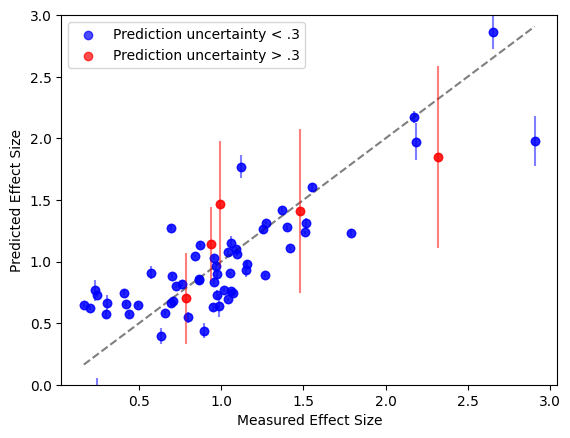

R^2: 0.735
Mean absolute error: 0.2401
-----
R^2 removing high uncertainty: 0.736
MAE removing high uncertainty: 0.2385


In [19]:
#up to thrid order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_3(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 5)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

In [21]:
#up to second order terms

def add_cross_terms_2(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))


    data = np.hstack((data, cross_factors))

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


Iteration 1 finished with AIC 59.28
Iteration 1001 finished with AIC 46.89
Iteration 2001 finished with AIC 60.97
Iteration 3001 finished with AIC 66.37
Iteration 4001 finished with AIC 72.81
Iteration 5001 finished with AIC 66.46
Iteration 6001 finished with AIC 69.6
Iteration 7001 finished with AIC 66.84
Iteration 8001 finished with AIC 54.06
Iteration 9001 finished with AIC 60.33


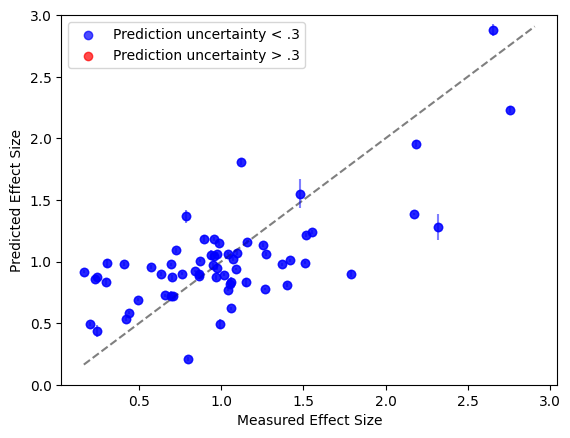

R^2: 0.578
Mean absolute error: 0.2997
-----
R^2 removing high uncertainty: 0.578
MAE removing high uncertainty: 0.2997


In [22]:
#up to second order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_2(data)

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 5)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)

Iteration 1 finished with AIC 106.99
Iteration 1001 finished with AIC 106.99
Iteration 2001 finished with AIC 106.99
Iteration 3001 finished with AIC 106.99
Iteration 4001 finished with AIC 107.67
Iteration 5001 finished with AIC 106.99
Iteration 6001 finished with AIC 106.99
Iteration 7001 finished with AIC 106.99
Iteration 8001 finished with AIC 106.99
Iteration 9001 finished with AIC 106.99


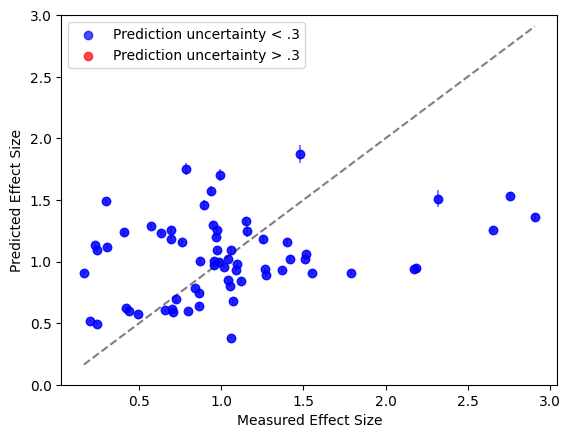

R^2: 0.087
Mean absolute error: 0.4419
-----
R^2 removing high uncertainty: 0.087
MAE removing high uncertainty: 0.4419


In [23]:
#first order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = data

keepers, AICs, good_fits = feature_selection(data, target, its=10000, n =1, prt = True, num_choose = 5)

LOO_predictions_mean, LOO_predictions_std, LOO_weights = bootstrap_LOO(data, target, keepers, good_fits, bootstrap_n=300)

LOO_plot(target, LOO_predictions_mean, LOO_predictions_std)